# Classification-Tree
- Squence of if-else questions about individual features
- Objective : infer class labels
- Able to capture non-linear relationships
- Don't require feature scaling (ex Standardization)

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

In [2]:
df = pd.read_csv('breast-cancer.csv')

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Text(0.5, 0, 'concave points_mean')

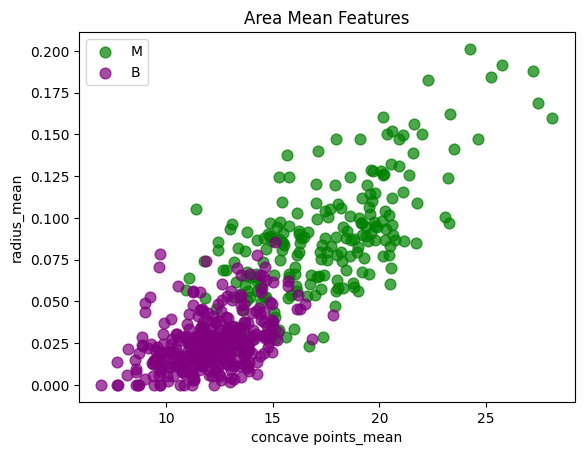

In [4]:
for diagnosis in df['diagnosis'].unique() :
    subset = df[df['diagnosis'] == diagnosis]
    if diagnosis == 'M':
        color = 'green'
        marker = 'o'
        label = 'M'
    else:
        color = 'purple'
        marker = '^'
        label = 'B'
        marker = 'o'
    plt.scatter( subset['radius_mean'],subset['concave points_mean'], c=color, marker=marker, label=label, alpha=0.7, s=60)
plt.title("Area Mean Features")
plt.legend()
plt.ylabel("radius_mean")
plt.xlabel("concave points_mean")

In [5]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['diagnosis'])

# Classification-Tree in sickit learn

In [6]:
# ensure X and y are numpy arrays (avoid pyarrow-backed arrays which don't support advanced indexing)
X = df.drop('diagnosis', axis=1).to_numpy()
y_labels = df['diagnosis'].to_numpy()


X_train, X_test, y_train, y_test = train_test_split(X, y_labels, test_size=0.2, stratify=y_labels, random_state=1)

dt = DecisionTreeClassifier(max_depth=2, random_state=1)

In [7]:
# fit dt to the training set
dt.fit(X_train,y_train)

# Predict the test 
y_pred = dt.predict(X_test)

# Evaluate Score
accuracy_score(y_test,y_pred)


0.9035087719298246

# Building Blocks of a Decision-Tree
- Decision-Tree : data structure consisting of a hierarchy of nodes 
- Node : question or prediction

### Three kind of nodes 
- Root : no parent node , question giving rise to two children nodes
- Internal node : one parent node , question giving rise to two children nodes.
- Leaf : one parent node , no children nodes --> prediction

1. What is a classification tree doing?
- Classification tree tries to seperate data into classes as cleanly as possible
- It starts with all samples at the root node 
- Then it splits the data repeatedly
- Each split asks a yes/no question like
    - Is a feature f <= split-point
- This process continues recursively until :
    - The node is already "pure" or 
    - A stopping condition is met (max depth , minimum samples etc)
2. What is a "pure" node 
- A node is pure if all samples belong to the same class
    - Node A : 100 samples --> all are class 1 (pure)
    - Node B : 50 samples --> 25 class 0 , 25 class 1 (impure)
3. How does the tree decide where to split
    - at each node the tree must decide which feature to use ?
    - which split point sp for that feature
- It does this by trying many possible splits and choosing the one that gives the maximum information guide 

### Information Gain
- Information Gain tells us how much uncertainty is reduced by a split.
- Information Gain=Entropy(parent)−Weighted Entropy(children)

### Criteria to measure the impurity of a node I(node)
- gini index 
- entropy


# How does a tree learn
- When an unconstrained tree is trained the nodes are grown recursively.
- In other words , a node exists based on the state of its predcessors (a thing that has been followed or replaced by another.)
- At each node data split is based on :
    - Feature f and split point p to maximize IG(node)
- if IG(node) = 0 declare the node leaf
-f you constrain the maximum depth of a tree to 2 for example, all nodes having a depth of 2 will be declared leafs even if the information gain obtained by splitting such nodes is not null.

# Using gini Criteria

In [8]:
X = df.drop('diagnosis', axis=1).to_numpy()
y_labels = df['diagnosis'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y_labels, test_size=0.2, stratify=y_labels, random_state=1)

dt = DecisionTreeClassifier(criterion='gini', random_state=1)
# fit dt to the training set
dt.fit(X_train,y_train)

# Predict the test 
y_pred = dt.predict(X_test)

# Evaluate Score
accuracy_score(y_test,y_pred)

0.9298245614035088

# Using Entropy Criteria

In [9]:
X = df.drop('diagnosis', axis=1).to_numpy()
y_labels = df['diagnosis'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y_labels, test_size=0.2, stratify=y_labels, random_state=1)

dt = DecisionTreeClassifier(criterion='entropy', random_state=1)
# fit dt to the training set
dt.fit(X_train,y_train)

# Predict the test 
y_pred = dt.predict(X_test)

# Evaluate Score
accuracy_score(y_test,y_pred)

0.9385964912280702

# Ensemble Learning

## Advantages of Cart
- Simple to understand
- Simple to interpret 
- Easy to use 
- Flexibility : ability to describe non linear dependencies
- Preprocessing : no need to standardize or normalize features

## Limitations of Cart
- Classification : can only produce orthogonal boundaries .
- Sensitive to small variations in the training set 
    - Sometimes when a single point is removed from training set a CART's learned parameter may change drastically
- High Variance : unconstrained CARTs may overfit the training set 
- Solution : Ensemble learning

## Ensemble Learning Summary 
- train different models on the same dataset 
- let each model make its prediction 
- Meta model : aggregates predictions of individual models 
- Final prediction : more robust and less prone to errors
- Best results : models are skillful in different ways


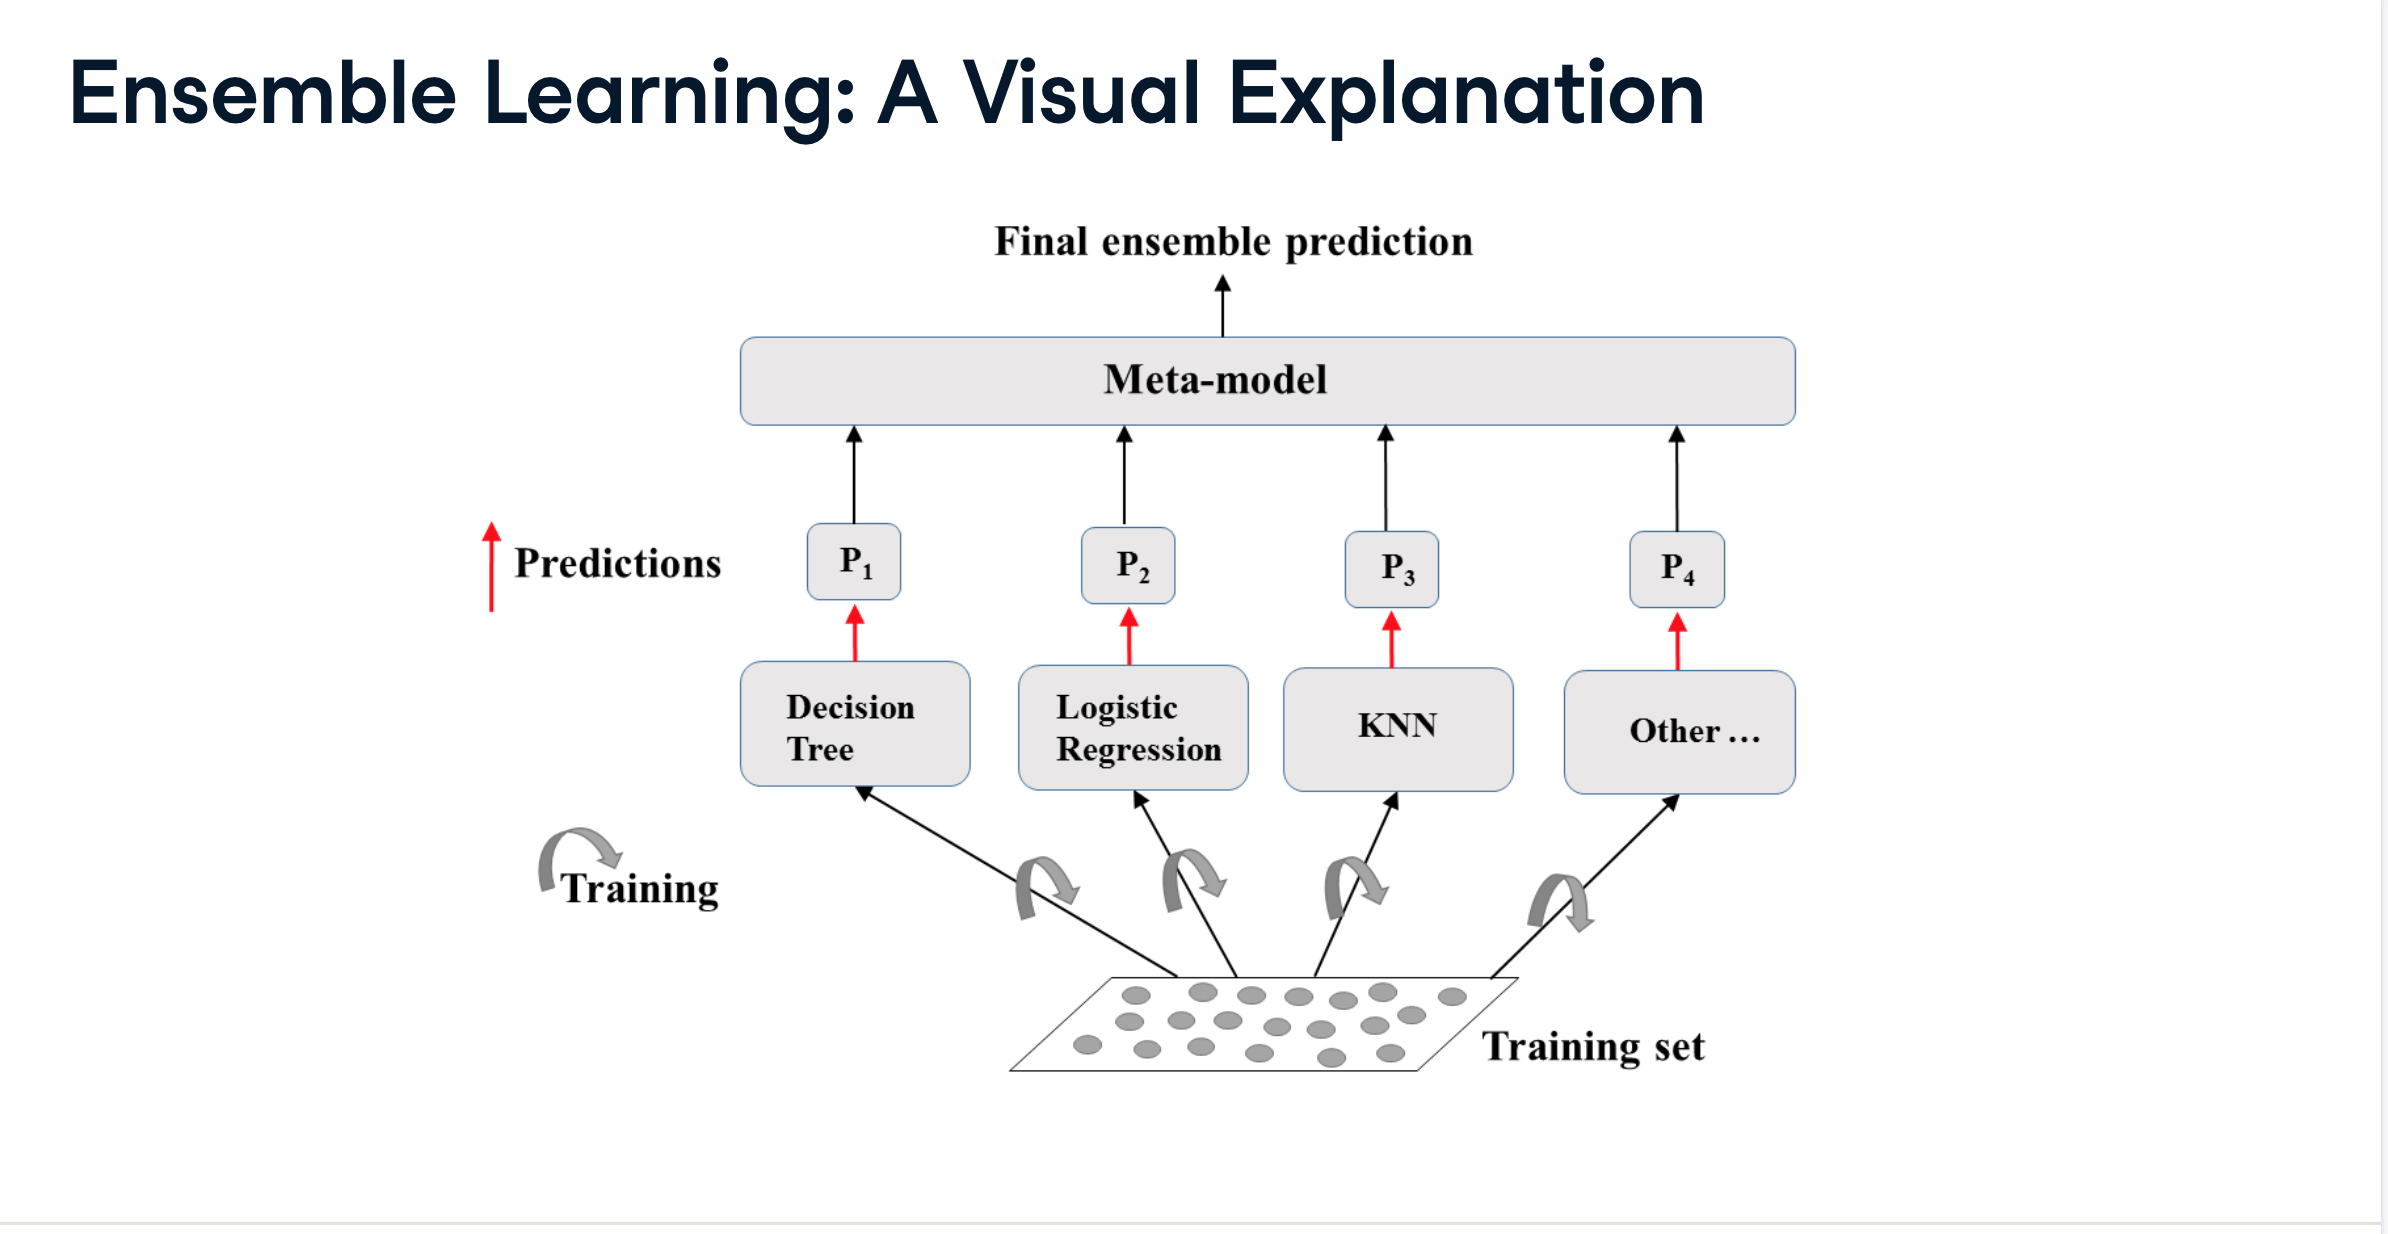

### Ensemble Visualization
- First the training set is fed to different classifiers . Each classifier learns its parameters and make predictions are fed to a meta model which aggregates then and outputs a final prediction

### Ensemble learning in practice : Voting Classifier 
- Binary Classification task .
- N classifiers make predictions : P1,P2 ...... Pi to 1 or 0
- Meta models predictions through hard voting

### Hard Voting
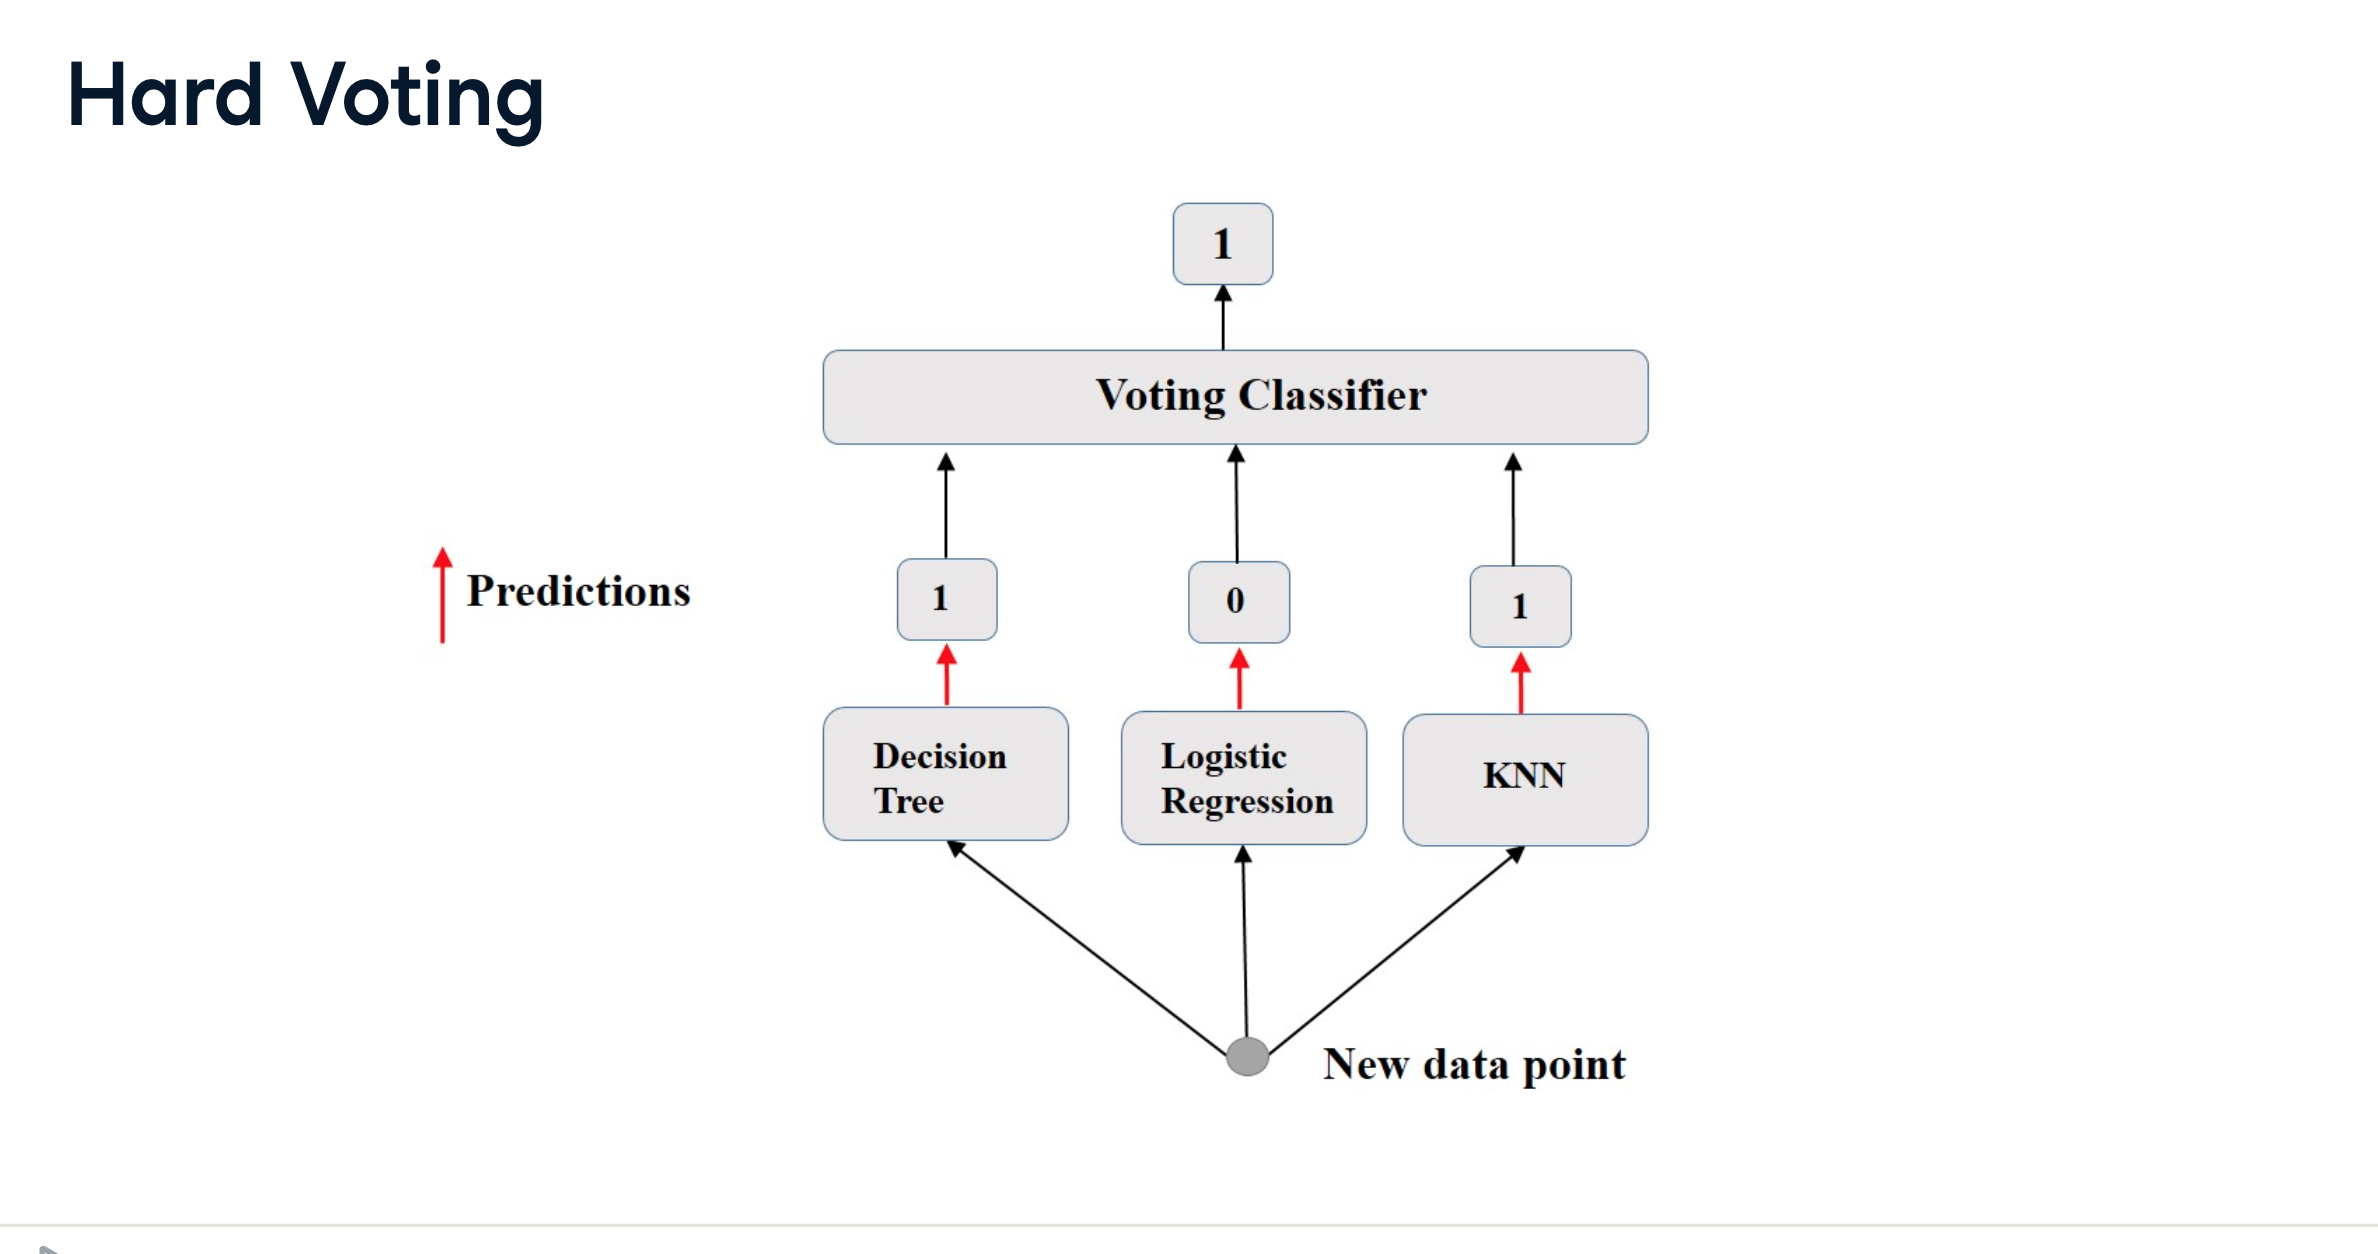
- To understand hard voting, consider a voting classifier that consists of 3 trained classifiers as shown in the diagram here. While classifiers 1 and 3 predict the label of 1 for a new data-point, classifier 2 predicts the label 0. In this case, 1 has 2 votes while 0 has 1 vote. As a result, the voting classifier predicts 1.

# Voting Classifier in sklearn (Brest Cancer)



In [18]:
# Split the data into 70% train 30% test
SEED = 123
X_train, X_test, y_train, y_test = train_test_split(X, y_labels, test_size=0.2, stratify=y_labels, random_state=SEED)

# instantiate individual classifiers
lr = LogisticRegression(random_state=SEED)
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier(random_state=SEED)


classifiers = [('logistic Regression', lr ), ("K Nearest Neighbours" , knn) , ("Classification Tree" , dt) ] 

for clf_name , clf in classifiers:
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)

    # Evaluation of score
    # print('{:s} : {:.3f}'.format(clf_name,accuracy_score(X_test,y_test)))
    print(f"{clf_name} : {accuracy_score(y_test, y_pred):.3f}")

vc = VotingClassifier(estimators=classifiers)

vc.fit(X_train,y_train)
y_pred = vc.predict(X_test)

# Evaluating the best score
print(f"Voting Classifier : {accuracy_score(y_test, y_pred):.3f}")


logistic Regression : 0.886
K Nearest Neighbours : 0.719
Classification Tree : 0.912
Voting Classifier : 0.921


/Users/apple/Documents Local/Mubashir Code/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/apple/Documents Local/Mubashir Code/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
 